# Data analysis of the history.parquet file

### Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import ast

In [9]:
history = pd.read_parquet("./datas/ebnerd_demo/train/history.parquet")

display(history.head())
history.info()

,user_id,impression_time_fixed,scroll_percentage_fixed,article_id_fixed,read_time_fixed
0,13538,"[2023-04-27T10:17:43.000000, 2023-04-27T10:18:...","[100.0, 35.0, 100.0, 24.0, 100.0, 23.0, 100.0,...","[9738663, 9738569, 9738663, 9738490, 9738663, ...","[17.0, 12.0, 4.0, 5.0, 4.0, 9.0, 5.0, 46.0, 11..."
1,58608,"[2023-04-27T18:48:09.000000, 2023-04-27T18:48:...","[37.0, 61.0, 100.0, 100.0, 55.0, 100.0, 100.0,...","[9739362, 9739179, 9738567, 9739344, 9739202, ...","[2.0, 24.0, 72.0, 65.0, 11.0, 4.0, 101.0, 0.0,..."
2,95507,"[2023-04-27T15:20:28.000000, 2023-04-27T15:20:...","[60.0, 100.0, 100.0, 21.0, 29.0, 67.0, 49.0, 5...","[9739035, 9738646, 9634967, 9738902, 9735495, ...","[18.0, 29.0, 51.0, 12.0, 10.0, 10.0, 13.0, 24...."
3,106588,"[2023-04-27T08:29:09.000000, 2023-04-27T08:29:...","[24.0, 57.0, 100.0, nan, nan, 100.0, 100.0, 73...","[9738292, 9738216, 9737266, 9737556, 9737657, ...","[9.0, 15.0, 42.0, 9.0, 3.0, 58.0, 26.0, 214.0,..."
4,617963,"[2023-04-27T14:42:25.000000, 2023-04-27T14:43:...","[100.0, 100.0, nan, 46.0, 23.0, 19.0, 61.0, 70...","[9739035, 9739088, 9738902, 9738968, 9738760, ...","[45.0, 29.0, 116.0, 26.0, 34.0, 42.0, 58.0, 59..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590 entries, 0 to 1589
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  1590 non-null   uint32
 1   impression_time_fixed    1590 non-null   object
 2   scroll_percentage_fixed  1590 non-null   object
 3   article_id_fixed         1590 non-null   object
 4   read_time_fixed          1590 non-null   object
dtypes: object(4), uint32(1)
memory usage: 56.0+ KB


In [19]:
history.isna().sum()/len(history)

user_id                    0.000000
impression_time_fixed      0.000000
scroll_percentage_fixed    0.000000
article_id_fixed           0.000000
read_time_fixed            0.000000
num_clicks                 0.000000
avg_read_time              0.000000
std_read_time              0.000000
avg_scroll                 0.925786
std_scroll                 0.925786
dtype: float64

The avg_scroll and std_scroll have a big proportion of NAN respectively 0.925786 and 0.925786. I don't understand why.

In [ ]:
print(f"Unique users: {history['user_id'].nunique()}")

Unique users: 1590


### Correlation matrix


In [12]:
import numpy as np

# Extract numerical summary features per user
history['num_clicks'] = history['article_id_fixed'].apply(len)
history['avg_read_time'] = history['read_time_fixed'].apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
history['std_read_time'] = history['read_time_fixed'].apply(lambda x: np.std(x) if len(x) > 0 else np.nan)
history['avg_scroll'] = history['scroll_percentage_fixed'].apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
history['std_scroll'] = history['scroll_percentage_fixed'].apply(lambda x: np.std(x) if len(x) > 0 else np.nan)


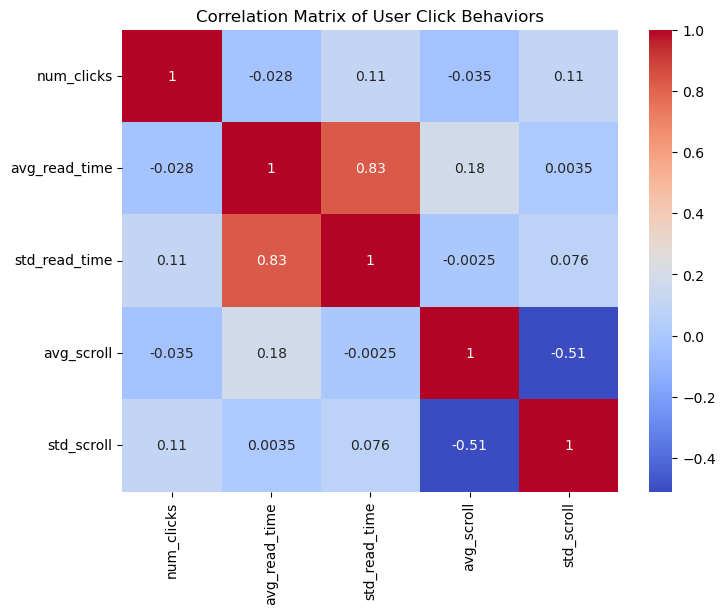

In [15]:
numeric_cols = ['num_clicks', 'avg_read_time', 'std_read_time', 'avg_scroll', 'std_scroll']
correlation_matrix = history[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of User Click Behaviors")
plt.show()
